# Introduction

- Spatial Distance-Based Proportion Analysis — Fig 5E/F/G/I & SuppFig 7F/G/H
- Computes proportion of cell types within sliding distance bins from Epithelial cells or CD8T cells

In [1]:
fig.size <- function(h, w) {
    options(repr.plot.height = h, repr.plot.width = w)
}

library(dplyr)
library(purrr)
library(ggplot2)
library(ggthemes)
library(patchwork)
library(ggpubr)
library(lme4)
library(FNN)
library(rmcorr)


Warning message:
“package ‘dplyr’ was built under R version 4.1.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘lme4’ was built under R version 4.1.3”
Loading required package: Matrix



# Read

In [ ]:
fdir <- file.path(".")

cell_meta <- readRDS(file.path(fdir, "cell_meta.rds"))
tile_meta <- readRDS(file.path(fdir, "tile_meta.rds"))
sample_meta <- readRDS(file.path(fdir, "sample_meta.rds"))
celltype_meta <- readRDS(file.path(fdir, "celltype_meta.rds"))

# Annotate distance

Calculate nearest distance to specified cell type for every cell

In [3]:
compute_nn_dist <- function(
    df,
    target,
    celltype_col,
    sample_col="new_specimenID",
    x_col="x_mod",
    y_col="y_mod"
){
    df <- as.data.frame(df)
    out_df <- purrr::map(unique(df[[sample_col]]), function(.sample){
        sub_df <- df %>% 
            filter(.data[[sample_col]] == .sample)
        ref_df <- sub_df %>% 
            filter(.data[[celltype_col]] == target)
        sub_df[[paste0("dist_to_", target)]] <- knnx.dist(
            data=as.matrix(ref_df[, c(x_col, y_col)]),
            query=as.matrix(sub_df[, c(x_col, y_col)]), k=1)[, 1]
        return(sub_df)
    }) %>% 
    bind_rows()
    return(out_df)
}

In [4]:
cell_meta <- compute_nn_dist(
    df=cell_meta, target="CD8T", celltype_col="celltype_lvl_2")

In [5]:
cell_meta <- compute_nn_dist(
    df=cell_meta, target="Epithelial", celltype_col="celltype_level_1")

# Function

In [ ]:
df_wilcox_test <- function(df, group_1 = "on", group_2 = "pre",
                           group_var = "new_treatment"){
    vec_1 <- df %>% filter(.data[[group_var]] == group_1) %>% pull(prop)
    vec_2 <- df %>% filter(.data[[group_var]] == group_2) %>% pull(prop)
    if(length(vec_1) <= 1 | length(vec_2) <= 1) return(NA)
    test_res <- wilcox.test(vec_1, vec_2)
    res <- list(
        pvalue=test_res$p.value, mean_diff=mean(vec_1) - mean(vec_2),
        fc=mean(vec_1)/mean(vec_2))
    res
}

compute_prop_df <- function(deno_celltype, deno_var, nume_var, .dist_var,
                            bin_df, cell_meta, num_cell_cutoff){
    .df <- purrr::pmap(bin_df, function(dist_bin, dist_min, dist_max){
        .df <- cell_meta %>% 
            filter(.data[[deno_var]]==deno_celltype) %>% 
            mutate(celltype=factor(factor(.data[[nume_var]]))) %>% 
            filter(.data[[.dist_var]] >= dist_min & .data[[.dist_var]] <= dist_max)
        if(length(unique(.df$new_specimenID)) <= 1) return(NULL)
        .df <- .df %>% 
            count(new_specimenID, new_treatment, celltype, .drop=FALSE) %>% 
            group_by(new_specimenID, new_treatment) %>% 
            mutate(nTotal=sum(n), prop=n/nTotal, dist_bin=dist_bin, dist_var=.dist_var) %>% 
            ungroup()
        return(.df)
    }) %>% 
        bind_rows() %>% 
        filter(nTotal >= num_cell_cutoff)
    return(.df)
}

compute_stat_df <- function(prop_df){
    stat_df <- prop_df %>% 
        group_by(dist_bin, celltype, dist_var) %>% 
        summarise({
            res <- df_wilcox_test(pick(everything()))
            data.frame(
                pvalue=res$pvalue, signed_logpvalue=-log10(res$pvalue)*sign(res$mean_diff),
                fc=res$fc, num_sample=n())
        }, .groups="drop")
    stat_df
}

make_dist_prop_plot <- function(prop_df, stat_df, .dist_var, .celltype, plot_params) {
    list2env(plot_params, envir = environment())

    .stat <- stat_df %>%
        mutate(sig_type = case_when(
            signed_logpvalue > -log10(0.05) ~ "on>pre",
            signed_logpvalue < log10(0.05)  ~ "pre>on",
            .default = "insignificant"
        ))
    
    min_numsample <- min(.stat$num_sample)
    max_numsample <- max(.stat$num_sample)
    
    p1 <- .stat %>%
        ggplot(aes(x = dist_bin, y = signed_logpvalue)) +
            geom_vline(xintercept = 0, linetype = "dashed") +
            geom_vline(xintercept = bin_radius, linetype = "dashed") +
            geom_hline(yintercept = 0, linetype = "dashed") +
            geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "red") +
            geom_hline(yintercept = log10(0.05), linetype = "dashed", color = "blue") +
            geom_line() +
            geom_point(aes(color = sig_type, size = num_sample), alpha = .5) +
            scale_x_continuous(breaks = x_breaks) +
            scale_color_manual(values = pvalue_colvec) +
            scale_size_continuous(
                limits = c(min_numsample - 2, NA),
                breaks = c(min_numsample, round(mean(range(.stat$num_sample))),
                           max_numsample)) +
            theme_classic(base_size = 20) +
            guides(color = guide_legend(override.aes = list(shape = 16, size = 7))) +
            labs(title    = paste0(.celltype),
                 subtitle = paste0(subtitle, "\n", .dist_var),
                 y="signed log10 p-value", color="", size="") +
            theme(axis.text.x   = element_text(angle = 45, hjust = 1),
                  plot.title    = element_text(size = 20),
                  plot.subtitle = element_text(size = 15))

    .prop <- prop_df %>% 
        group_by(new_treatment, celltype, dist_bin) %>% 
        summarise(mean=mean(prop), n_sample=n(), se=sd(prop)/sqrt(n_sample),
                  .groups="drop")
    min_numsample <- min(.prop$n_sample)
    max_numsample <- max(.prop$n_sample)
    
    p2 <- .prop %>%
        ggplot(aes(x = dist_bin, y = mean)) +
            geom_vline(xintercept = 0, linetype = "dashed") +
            geom_vline(xintercept = bin_radius, linetype = "dashed") +
            geom_line(aes(color = new_treatment)) +
            geom_point(aes(color = new_treatment, size = n_sample), alpha = .5) +
            geom_errorbar(
                aes(ymin = mean-se, ymax = mean+se, color = new_treatment),
                width = 2, alpha = .5) +
            theme_classic(base_size = 20) +
            scale_x_continuous(breaks = x_breaks) +
            scale_color_manual(values = treatment_colvec) +
            scale_size_continuous(
                limits = c(min_numsample - 2, NA),
                breaks = c(min_numsample, round(mean(range(.prop$n_sample))),
                           max_numsample)) +
            theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
            guides(color = guide_legend(override.aes = list(shape = 16, size = 7))) +
            labs(x=expression(paste(mu, "m")), y=y_lab, color="", size="")

    (p1 / p2) + plot_layout(axes = "collect", heights = c(2, 3))
}

analyze_dist_prop <- function(deno_celltype, deno_var, nume_var, .celltype,
                              .dist_var, bin_df, cell_meta, num_cell_cutoff,
                              plot_params){
    prop_df <- compute_prop_df(
        deno_celltype=deno_celltype, deno_var=deno_var, nume_var=nume_var, 
        .dist_var=.dist_var, bin_df=bin_df, cell_meta=cell_meta,
        num_cell_cutoff=num_cell_cutoff) %>% 
        filter(celltype==.celltype)
    stat_df <- compute_stat_df(prop_df)

    p <- make_dist_prop_plot(
        prop_df=prop_df, 
        stat_df=stat_df,
        .dist_var=.dist_var, .celltype=.celltype, plot_params=plot_params)   
    return(list(prop_df=prop_df, stat_df=stat_df, plot=p))
}


make_all_dist_prop_plot <- function(prop_df, stat_df, .dist_var, .celltype, plot_params) {
    list2env(plot_params, envir = environment())

    .prop <- prop_df %>% 
        group_by(celltype, dist_bin) %>% 
        summarise(mean=mean(prop), n_sample=n(), se=sd(prop)/sqrt(n_sample),
                  .groups="drop")
    min_numsample <- min(.prop$n_sample)
    max_numsample <- max(.prop$n_sample)
    
    plot <- .prop %>%
        ggplot(aes(x = dist_bin, y = mean)) +
            geom_vline(xintercept = 0, linetype = "dashed") +
            geom_vline(xintercept = bin_radius, linetype = "dashed") +
            geom_line() +
            geom_point(aes(size = n_sample), alpha = .5) +
            geom_errorbar(
                aes(ymin = mean-se, ymax = mean+se),
                width = 2, alpha = .5) +
            theme_classic(base_size = 20) +
            scale_x_continuous(breaks = x_breaks) +
            scale_size_continuous(
                limits = c(min_numsample - 2, NA),
                breaks = c(min_numsample, round(mean(range(.prop$n_sample))),
                           max_numsample)) +
            theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
            guides(color = guide_legend(override.aes = list(shape = 16, size = 7))) +
            labs(title=.celltype, subtitle=.dist_var,
                 x=expression(paste(mu, "m")), y=y_lab, size="")
    
    plot
}

# Set parameters

In [7]:
x_breaks   <- seq(0, 100, 10)
bin_radius <- 10
bin_vec    <- seq(10, 50, 5)
bin_list   <- bin_vec %>% purrr::map(function(x) c(x - bin_radius, x + bin_radius, x))
bin_df     <- data.frame(dist_bin=bin_vec, dist_min=bin_vec-bin_radius, dist_max=bin_vec+bin_radius)
bin_info   <- paste0(
    "bin width = ", bin_radius * 2, ", ",
    "bin for ",
    paste0(bin_list[[1]][3], ": ", bin_list[[1]][1], "_", bin_list[[1]][2]), ", ",
    paste0(bin_list[[2]][3], ": ", bin_list[[2]][1], "_", bin_list[[2]][2]), ", ..."
)
                                     
num_cell_cutoff <- 10
qc_cell_meta <- cell_meta %>% filter(new_specimenID != "xe_Pt21pre")

plot_params <- list(
    x_breaks         = x_breaks,
    bin_radius       = bin_radius,
    pvalue_colvec    = c("on>pre" = "red", "pre>on" = "blue", "insignificant" = "black"),
    treatment_colvec = c("on" = "#E15759", "pre" = "#4E79A7"),
    y_lab            = "mean prop",
    subtitle         = paste0(
        "wilcox.test, mean for point and SE for error bar, \n",
        bin_info, "\n",
        "keep bin with num_cell >= ", num_cell_cutoff, " per specimen per window"
    )
)

# plot

## On vs Pre

In [8]:
.df <- data.frame(
    deno_celltype=c("T", "T", "Myeloid", "T", "Myeloid", "Myeloid"),
    deno_var=c("celltype_level_1", "celltype_level_1", "celltype_level_1", "celltype_level_1", "celltype_level_1", "celltype_level_1"),
    nume_var=c("celltype_lvl_2", "celltype_simplified", "celltype_finest_lvl", "celltype_lvl_2", "celltype_finest_lvl", "celltype_finest_lvl"), 
    celltype=c("CD8T", "Activated_CD8T", "CXCL10 mac_mye", "CD4T", "CXCL10 mac_mye", "SPP1 mye_mye"),
    dist_var=c("dist_to_Epithelial", "dist_to_Epithelial", "dist_to_CD8T", "dist_to_Epithelial", "dist_to_Epithelial", "dist_to_Epithelial")
) 
res_list <- .df %>% 
    purrr::pmap(function(deno_celltype, deno_var, nume_var, celltype, dist_var){
        res <- analyze_dist_prop(
            deno_celltype=deno_celltype, deno_var=deno_var, nume_var=nume_var,
            .celltype=celltype, .dist_var=dist_var, bin_df=bin_df,
            cell_meta=qc_cell_meta, num_cell_cutoff=num_cell_cutoff,
            plot_params=plot_params)
        res
    })
names(res_list) <- paste0(.df$celltype, "_", .df$dist_var)

Warning message:
“There were 5 warnings in `summarise()`.
The first warning was:
ℹ In argument: `{ ... }`.
ℹ In group 3: `dist_bin = 20`, `celltype = CD8T`, `dist_var =
  "dist_to_Epithelial"`.
Caused by warning in `wilcox.test.default()`:
! cannot compute exact p-value with ties
ℹ Run `dplyr::last_dplyr_warnings()` to see the 4 remaining warnings.”
Warning message:
“There were 3 warnings in `summarise()`.
The first warning was:
ℹ In argument: `{ ... }`.
ℹ In group 7: `dist_bin = 40`, `celltype = Activated_CD8T`, `dist_var =
  "dist_to_Epithelial"`.
Caused by warning in `wilcox.test.default()`:
! cannot compute exact p-value with ties
ℹ Run `dplyr::last_dplyr_warnings()` to see the 2 remaining warnings.”
Warning message:
“There were 2 warnings in `summarise()`.
The first warning was:
ℹ In argument: `{ ... }`.
ℹ In group 6: `dist_bin = 35`, `celltype = CXCL10 mac_mye`, `dist_var =
  "dist_to_CD8T"`.
Caused by warning in `wilcox.test.default()`:
! cannot compute exact p-value with ties
ℹ

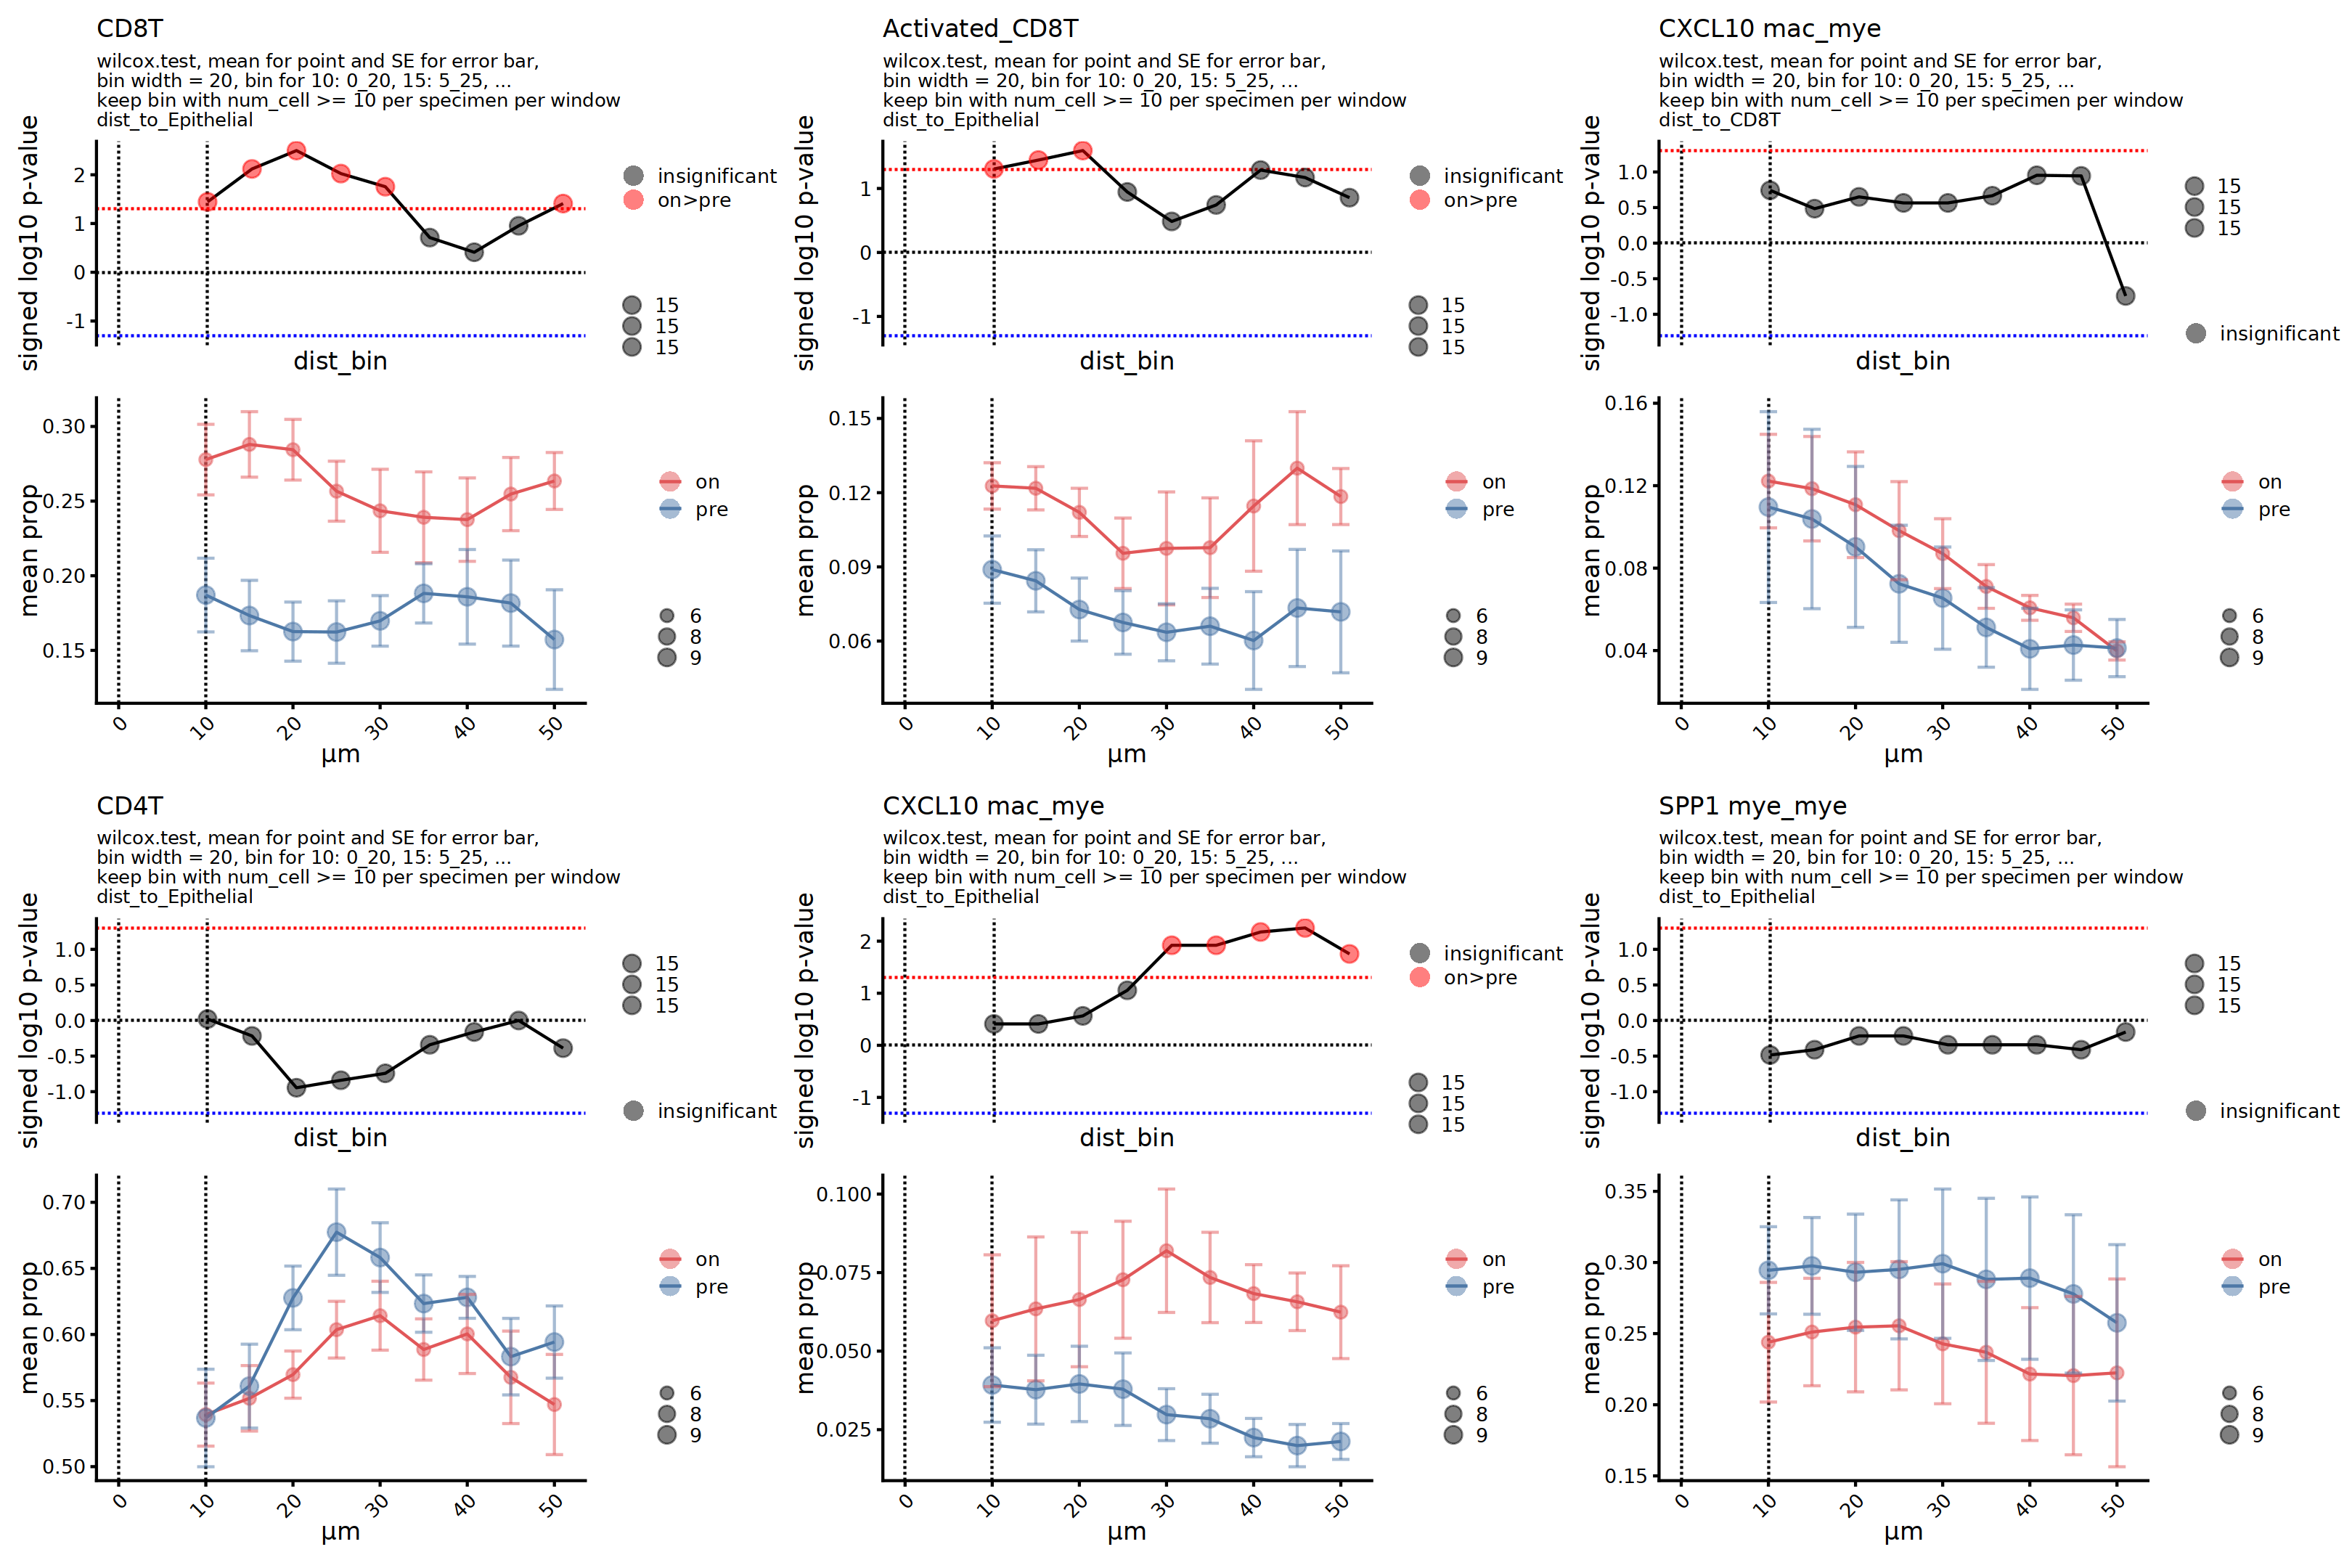

In [9]:
p_prop_50 <- purrr::map(res_list, function(res){res$plot})  %>% wrap_plots(ncol=3)

fig.size(18, 27)
p_prop_50

In [10]:
fig.size(9, 8)
purrr::map(res_list, function(res){
    res$stat_df %>% 
        mutate(fdr=p.adjust(pvalue, method = "fdr"), significant=if_else(fdr<0.1, "Yes", "No"))
}) 

dist_bin,celltype,dist_var,pvalue,signed_logpvalue,fc,num_sample,fdr,significant
<dbl>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<chr>
10,CD8T,dist_to_Epithelial,0.035964036,1.4441316,1.485032,15,0.05849264,Yes
15,CD8T,dist_to_Epithelial,0.007592408,2.1196205,1.661295,15,0.02837373,Yes
20,CD8T,dist_to_Epithelial,0.003188944,2.4963532,1.749304,15,0.02837373,Yes
25,CD8T,dist_to_Epithelial,0.009457911,2.0242048,1.581447,15,0.02837373,Yes
30,CD8T,dist_to_Epithelial,0.017582418,1.7549214,1.434327,15,0.03956044,Yes
35,CD8T,dist_to_Epithelial,0.194451829,0.7111880,1.270815,15,0.21875831,No
40,CD8T,dist_to_Epithelial,0.388411588,0.4107078,1.278094,15,0.38841159,No
45,CD8T,dist_to_Epithelial,0.111292007,0.9535360,1.401973,15,0.14308972,No
50,CD8T,dist_to_Epithelial,0.038995093,1.4089900,1.675632,15,0.05849264,Yes


## All

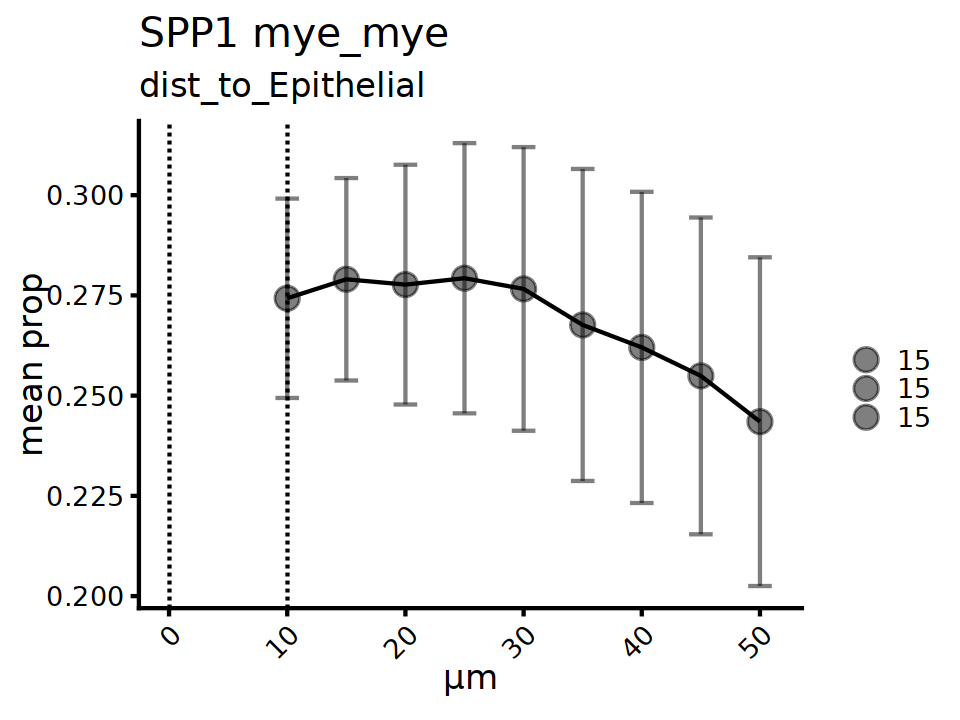

In [12]:
p_spp1mye <- make_all_dist_prop_plot(
    prop_df=res_list[["SPP1 mye_mye_dist_to_Epithelial"]]$prop_df,
    stat_df=res_list[["SPP1 mye_mye_dist_to_Epithelial"]]$stat_df,
    .dist_var="dist_to_Epithelial", .celltype="SPP1 mye_mye",
    plot_params=plot_params)
fig.size(6, 8)
p_spp1mye

## Extract stats

In [13]:
res_list[["CXCL10 mac_mye_dist_to_Epithelial"]]$stat_df %>% 
    filter(dist_bin>=30) %>% 
    mutate(p_median=signif(median(pvalue), 2), fc_median=signif(median(fc), 2))

dist_bin,celltype,dist_var,pvalue,signed_logpvalue,fc,num_sample,p_median,fc_median
<dbl>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
30,CXCL10 mac_mye,dist_to_Epithelial,0.011988012,1.921253,2.752164,15,0.012,2.9
35,CXCL10 mac_mye,dist_to_Epithelial,0.011988012,1.921253,2.579646,15,0.012,2.9
40,CXCL10 mac_mye,dist_to_Epithelial,0.006667723,2.176022,3.040377,15,0.012,2.9
45,CXCL10 mac_mye,dist_to_Epithelial,0.005571686,2.254013,3.298213,15,0.012,2.9
50,CXCL10 mac_mye,dist_to_Epithelial,0.017582418,1.754921,2.937818,15,0.012,2.9


# Regression

In [14]:
plot_sample <- function(df, title){
    plt <- df %>% 
        ggplot(aes(x=dist_bin, y=prop, color=new_specimenID)) +
            geom_line() +
            geom_point(aes(size = nTotal)) +
            scale_color_tableau("Tableau 20") +
            theme_classic(base_size=20) +
            labs(title=title) +
            NULL
    return(plt)
}

Warning message in theta.ml(Y, mu, weights = object@resp$weights, limit = limit, :
“iteration limit reached”


,Estimate,Std. Error,z value,Pr(>|z|)
(Intercept),-1.225814798,0.077437674,-15.829696,1.941584e-56
dist_bin,-0.008111545,0.004340872,-1.868644,6.167234e-02


Warning message in rmcorr(participant = new_specimenID, measure1 = dist_bin, measure2 = prop, :
“'new_specimenID' coerced into a factor”


[1] "rmcorr=-0.227521237984715"


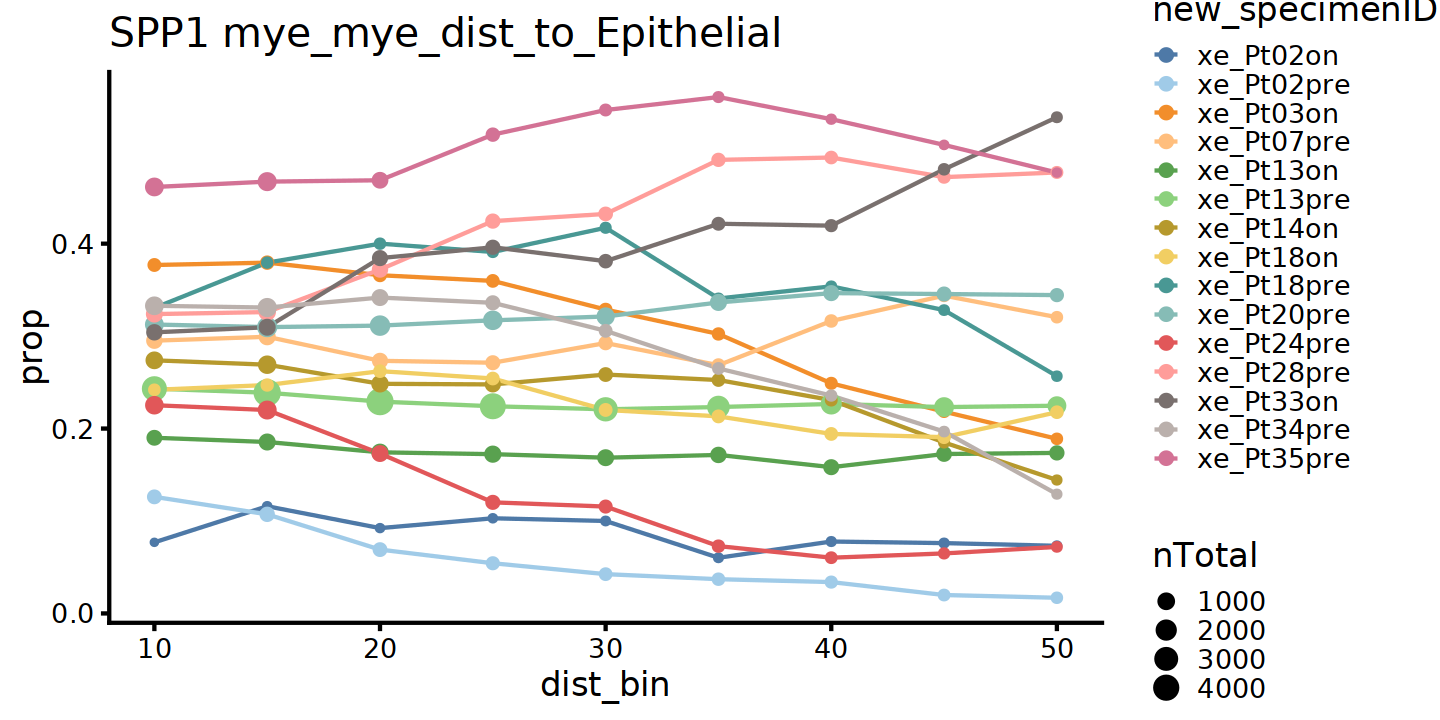

In [20]:
.target <- "SPP1 mye_mye_dist_to_Epithelial"
.df <- res_list[[.target]]$prop_df 
mod_fit <- glmer.nb(
    formula=n~dist_bin + (1+ dist_bin|new_specimenID) + offset(log(nTotal)), data=.df
)
summary(mod_fit)$coefficients
cor_res <- rmcorr(participant = new_specimenID, measure1=dist_bin, measure2=prop, dataset=.df) 
print(paste0("rmcorr=", cor_res$r))
plt <- plot_sample(.df, title=.target)
fig.size(6, 12)
plt

Warning message in theta.ml(Y, mu, weights = object@resp$weights, limit = limit, :
“iteration limit reached”


,Estimate,Std. Error,z value,Pr(>|z|)
(Intercept),-2.28920803,0.26644929,-8.591534,8.581608e-18
dist_bin,-0.02280904,0.00427171,-5.339558,9.317333e-08


Warning message in rmcorr(participant = new_specimenID, measure1 = dist_bin, measure2 = prop, :
“'new_specimenID' coerced into a factor”


[1] "rmcorr=-0.604539917738487"


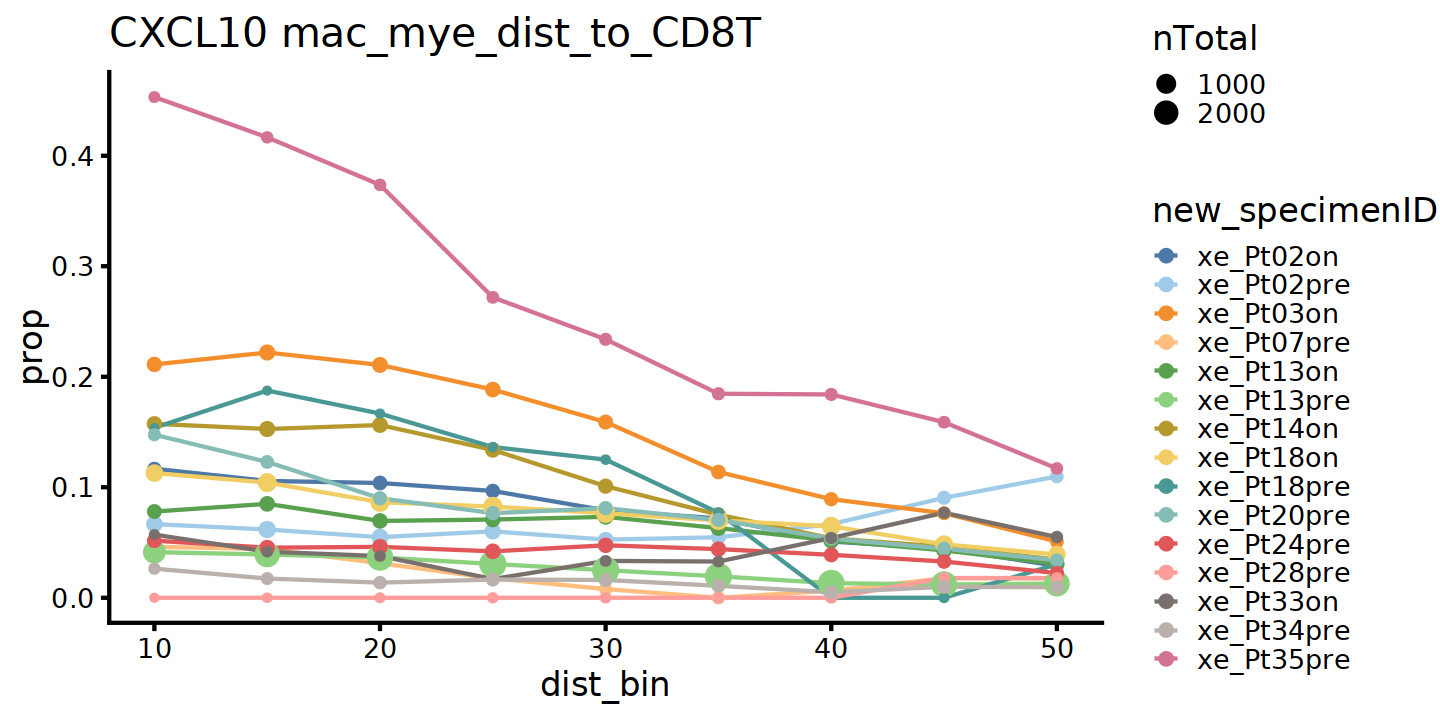

In [21]:
.target <- "CXCL10 mac_mye_dist_to_CD8T"
.df <- res_list[[.target]]$prop_df 
mod_fit <- glmer.nb(
    formula=n~dist_bin + (1+ dist_bin|new_specimenID) + offset(log(nTotal)), data=.df
)
summary(mod_fit)$coefficients
cor_res <- rmcorr(participant = new_specimenID, measure1=dist_bin, measure2=prop, dataset=.df) 
print(paste0("rmcorr=", cor_res$r))
plt <- plot_sample(.df, title=.target)
fig.size(6, 12)
plt

In [22]:
sessionInfo()

R version 4.1.2 (2021-11-01)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Red Hat Enterprise Linux 9.7 (Plow)

Matrix products: default
BLAS/LAPACK: /home/hoy821/miniforge3/lib/libopenblasp-r0.3.24.so

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] rmcorr_0.7.0    FNN_1.1.4.1     lme4_1.1-33     Matrix_1.6-1.1 
 [5] ggpubr_0.6.0    patchwork_1.3.2 ggthemes_4.2.4  ggplot2_4.0.1  
 [9] purrr_1.0.1     dplyr_1.1.2    

loaded via a namespace (and not attached):
 [1] Rcpp_1.0.11        lattice_0.21-8     tidyr_1.3.0        digest_0.6.31     